# Convex Hull Construction
The paper [Shahriar and Rahman (2013)](Shahriar%20and%20Rahman%20-%202013%20-%20Spatial-temporal%20prediction%20of%20algal%20bloom.pdf) explores a method to predict the motion of Harmful Algal Blooms (HABs) using a method where they construct a [convex hull](https://en.wikipedia.org/wiki/Convex_hull) around an existing group of algae (based up on measurements).


The goal of this notebook is to provide a simplified example of constructing this convex hull, mainly to explore the functions that Julia has available for constructing convex hulls.

We are using [`Meshes.jl`](https://juliageometry.github.io/MeshesDocs/stable/index.html) to provide the convex hull functionality.

In [24]:
# Imports
using Meshes, CairoMakie, Random, Unitful
import Meshes: Point, convexhull, centroid, rings, segments

In [25]:
############################################################
# Load satellite chlorophyll data and convert bloom pixels
# into Meshes.jl points
############################################################

using NCDatasets

# ---- Open the NetCDF file ----
filename = joinpath(
    pwd(),
    "requested_files",
    "AQUA_MODIS.20100617.L3m.DAY.CHL.x_chlor_a.nc"
)

ds = Dataset(filename)

# Read variables
chl = ds["chlor_a"][:, :]
lat = ds["lat"][:]
lon = ds["lon"][:]

close(ds)

# ---- Bloom threshold (mg/m^3) ----
threshold = 4.0

# ---- Convert qualifying pixels into Meshes.jl Points ----
raw_pts = Point[]

for j in eachindex(lat)
    for i in eachindex(lon)

        value = chl[i, j]

        if !ismissing(value) && value >= threshold
            
            push!(raw_pts, Point(
                Float64(lon[i]),
                Float64(lat[j])
            ))
        end

    end
end

println("Bloom pixels found: ", length(raw_pts))

println("First point:")
println(raw_pts[1])

println("Last point:")
println(raw_pts[end])
# Create the PointSet expected by the rest of the notebook
pts = PointSet(raw_pts)

Bloom pixels found: 123
First point:
Point(x: -82.59583282470703 m, y: 42.379310607910156 m)
Last point:
Point(x: -82.38749694824219 m, y: 41.42758560180664 m)


123 PointSet
├─ Point(x: -82.59583282470703 m, y: 42.379310607910156 m)
├─ Point(x: -82.55416107177734 m, y: 42.379310607910156 m)
├─ Point(x: -82.51249694824219 m, y: 42.379310607910156 m)
├─ Point(x: -82.47083282470703 m, y: 42.379310607910156 m)
├─ Point(x: -82.63749694824219 m, y: 42.33793258666992 m)
⋮
├─ Point(x: -82.55416107177734 m, y: 41.42758560180664 m)
├─ Point(x: -82.51249694824219 m, y: 41.42758560180664 m)
├─ Point(x: -82.47083282470703 m, y: 41.42758560180664 m)
├─ Point(x: -82.42916107177734 m, y: 41.42758560180664 m)
└─ Point(x: -82.38749694824219 m, y: 41.42758560180664 m)

In [26]:
# Construct the convex hull
hull = convexhull(pts)


PolyArea
  outer
  └─ Ring((x: -83.3875 m, y: 41.7586 m), ..., (x: -83.3875 m, y: 41.8 m))

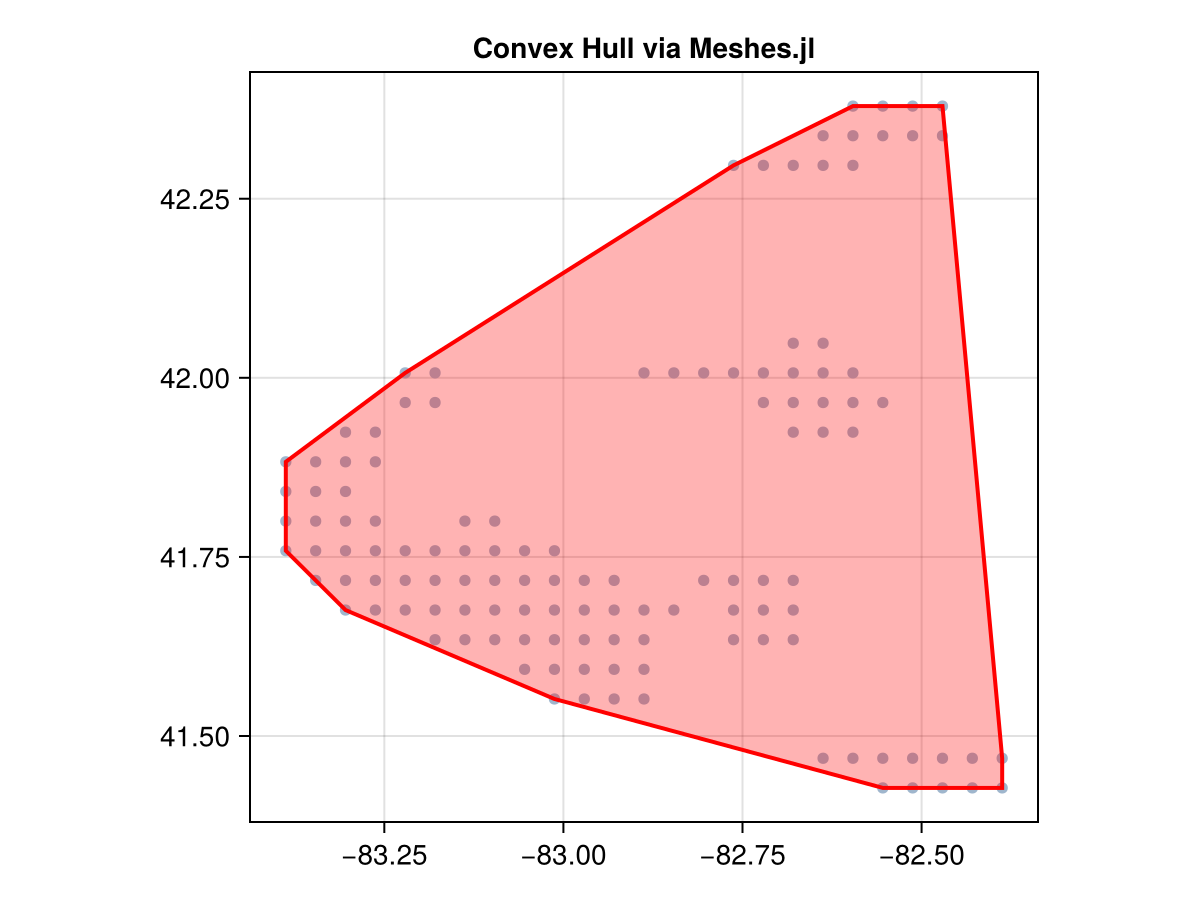

In [27]:
# Plot the figure
fig = Figure()
ax = Axis(fig[1, 1], title = "Convex Hull via Meshes.jl", aspect = DataAspect())

# 4. Use the specific segment properties allowed by the recipe
viz!(ax, pts, pointcolor = :black, pointsize = 8)
viz!(ax, hull, color = :red, alpha = 0.3, showsegments = true, segmentcolor = :red, segmentsize = 2)

fig

# Compressing convex hull into radii-based vector
In the paper above, they take the computed convex hull and represent it as a compressed vector with the centroid and $n$ radii representing the points of the boundary alongs various directions from the centroid.

We define a 38-element vector: the first two elements being the coordinates of the centroid, and each remaining element the radius at 10 degree increments from 0 (0 being North)

In [28]:
# Compute the Hull Centroid
c = centroid(hull)
cx = ustrip(c.coords.x);
cy = ustrip(c.coords.y);

c # print centroid coordinates

Point with Cartesian{NoDatum} coordinates
├─ x: -82.80222438299982 m
└─ y: 41.86576078292762 m

In [29]:
# Extract the boundary edges as segments to intersect against
outer_boundary = first(rings(hull))
hull_segments = segments(outer_boundary)

Base.Generator{UnitRange{Int64}, Meshes.var"#segments##0#segments##1"{CircularArrays.CircularVector{Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}, Vector{Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}}}}}(Meshes.var"#segments##0#segments##1"{CircularArrays.CircularVector{Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}, Vector{Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}}}}(Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}[Point(x: -83.38749694824219 m, y: 41.75862121582031 m), Point(x: -83.34583282470703 m, y: 41.71724319458008 m), Point(x: -83.30416107177734 m, y: 41.67586135864258 m), Point(x: -83.0124

In [30]:
# 3. Define 36 angles in degrees (0 = North/Up, moving clockwise)
angles_deg = 0:10:350

# Track the computed radii
radii = Float64[]

# Use a large bounding length to ensure ray segments fully exit the hull
max_radius = 2.0 

radii = Float64[]
visual_rays = Segment[]  # Storing the actual boundary-hitting segments

for deg in angles_deg
    rad = deg2rad(deg)
    dx, dy = sin(rad), cos(rad)
    
    target_point = Point(cx + max_radius * dx, cy + max_radius * dy)

    println(typeof(c))
    println(typeof(target_point))



    ray_segment = Segment(c, target_point)
    
    r_length = 0.0
    for edge in hull_segments
        intersect_result = ray_segment ∩ edge
        if intersect_result isa Point
            r_length = Float64(ustrip(Meshes.length(Segment(c, intersect_result))))
            
            # Save the truncated segment for plotting
            push!(visual_rays, Segment(c, intersect_result))
            break
        end
    end
    push!(radii, r_length)
end

compressed_vector = vcat([cx, cy], radii)

Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}
Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}
Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}
Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}
Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}
Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}
Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}
Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}


38-element Vector{Float64}:
 -82.80222438299982
  41.86576078292762
   0.40568696955143935
   0.4574613519401447
   0.533947598954625
   0.5929962593919
   0.5307844882085937
   0.45873369456736035
   0.4150086053627657
   0.3897041632280966
   0.37813739372043037
   0.3784036370075654
   0.3905451327089863
   ⋮
   0.464580590575175
   0.5398035299061795
   0.5943013379537315
   0.5852725652423629
   0.4992795293694428
   0.43347998025596846
   0.3873617108667643
   0.35999948984894464
   0.34606920156749066
   0.34321679335274174
   0.350988445533329
   0.37064292063153453

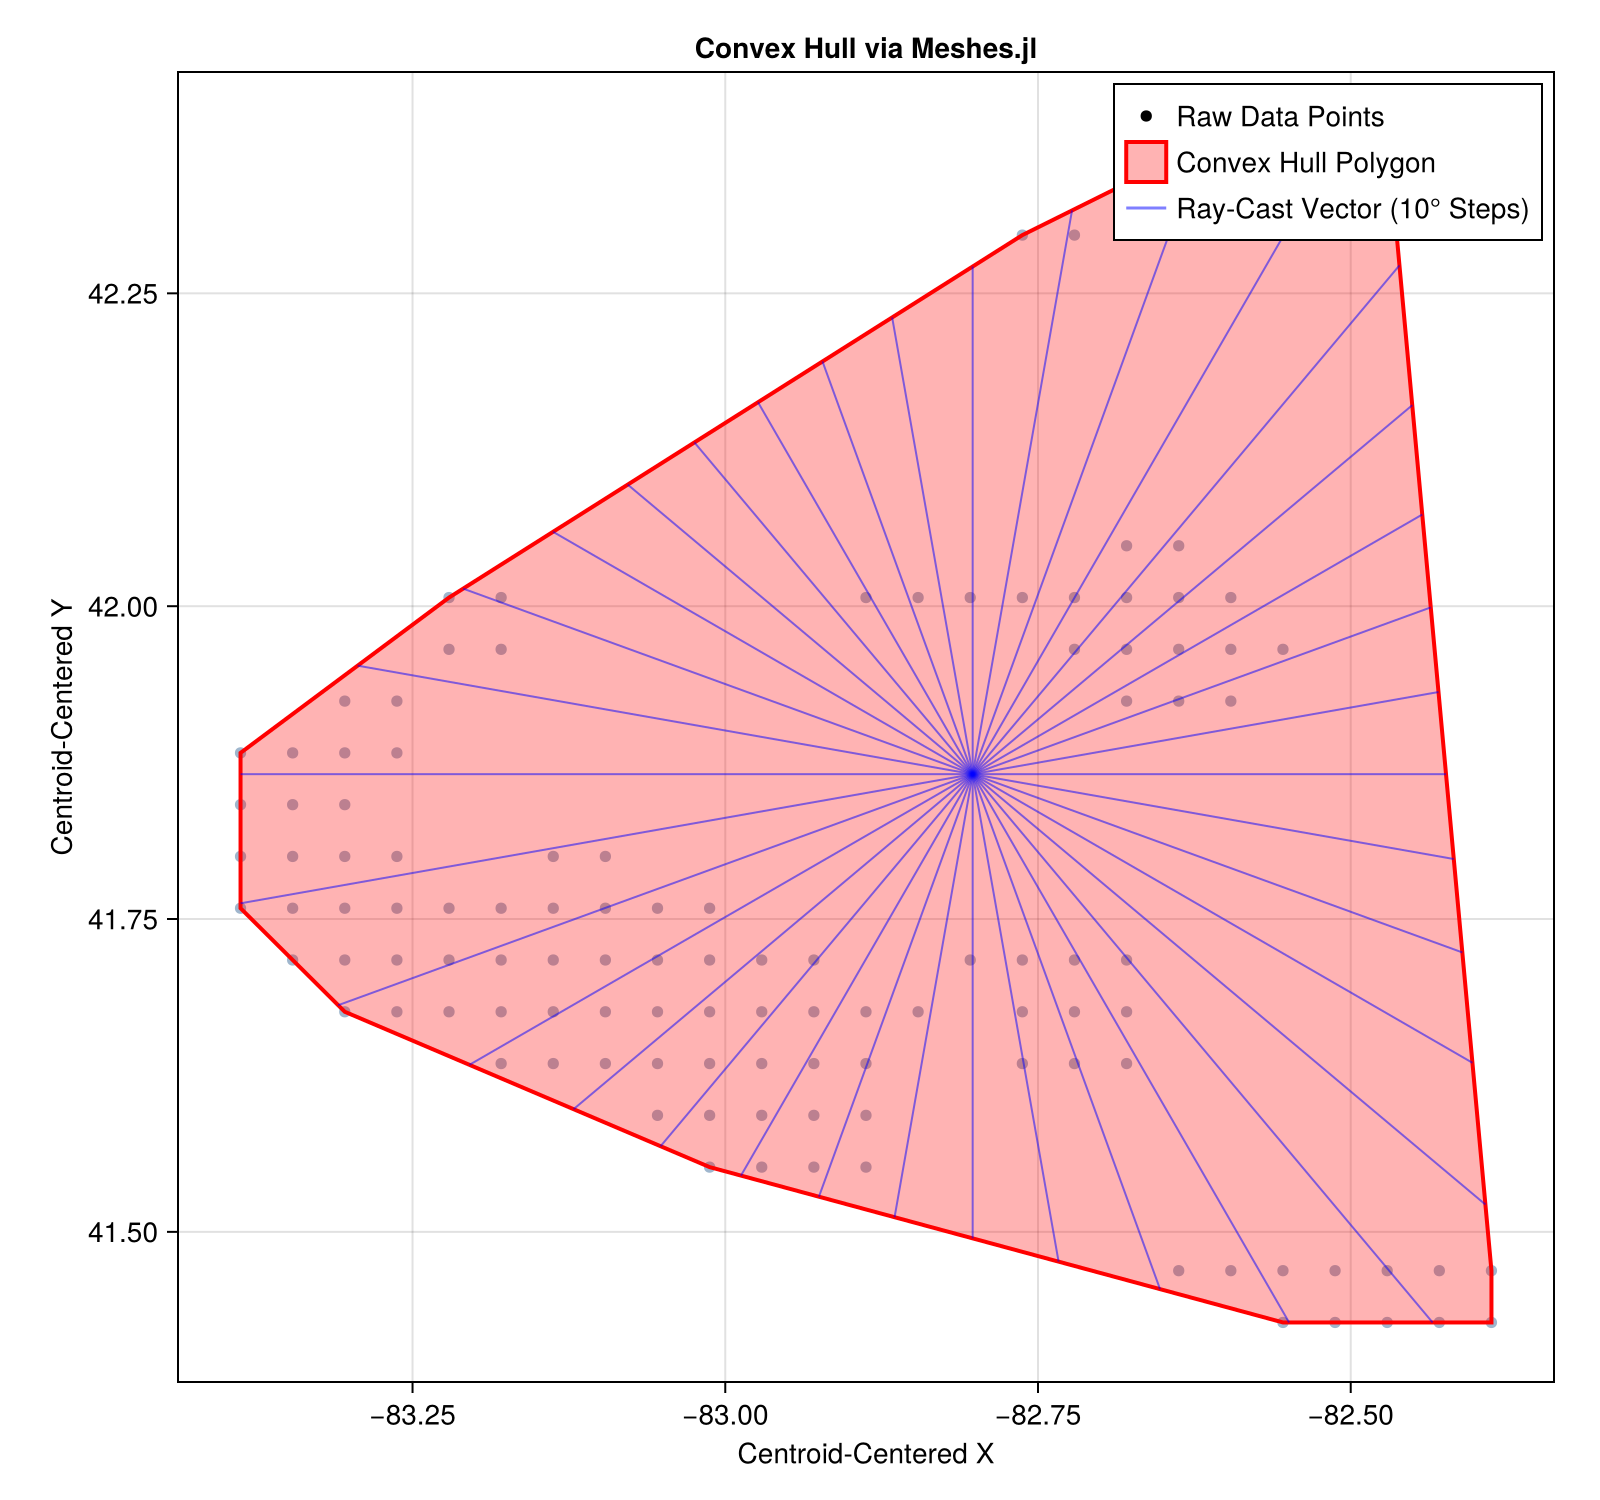

In [31]:
fig = Figure(size = (800, 750))
ax = Axis(fig[1, 1], title = "Convex Hull via Meshes.jl", aspect = DataAspect(),
          xlabel = "Centroid-Centered X", ylabel = "Centroid-Centered Y")

# 1. Plot the elements using your specific properties
viz!(ax, pts, pointcolor = :black, pointsize = 8)
viz!(ax, hull, color = :red, alpha = 0.3, showsegments = true, segmentcolor = :red, segmentsize = 2)
viz!(ax, GeometrySet(visual_rays), color = :blue, alpha = 0.5, segmentsize = 1)

# 2. Build explicit legend elements matching your visual configurations
elem_pts  = MarkerElement(color = :black, marker = :circle, markersize = 8)
elem_hull = PolyElement(color = (:red, 0.3), strokecolor = :red, strokewidth = 2)
elem_rays = LineElement(color = (:blue, 0.5), linewidth = 1.5)

# 3. Add the manual legend
axislegend(ax, 
    [elem_pts, elem_hull, elem_rays], 
    ["Raw Data Points", "Convex Hull Polygon", "Ray-Cast Vector (10° Steps)"],
    position = :rt
)

fig